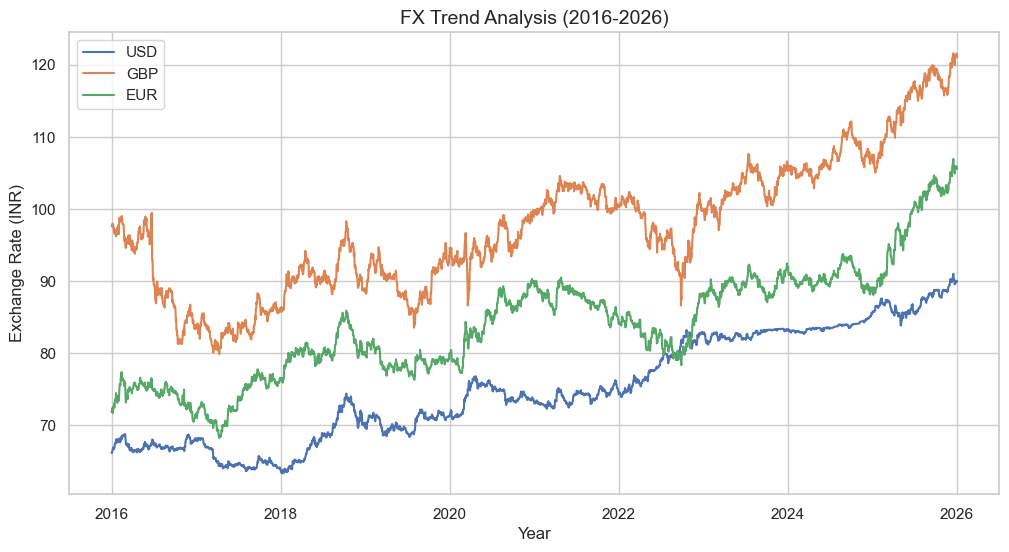

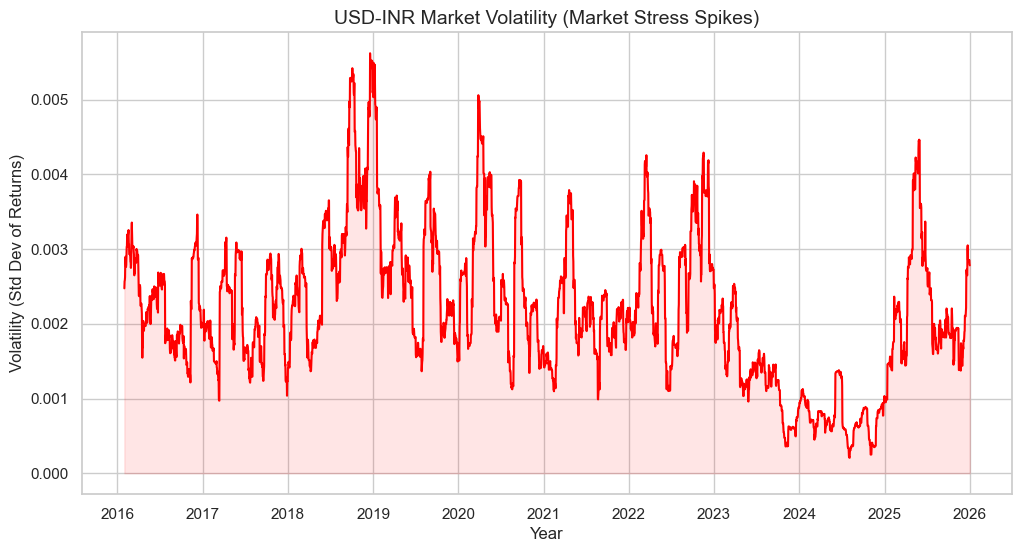

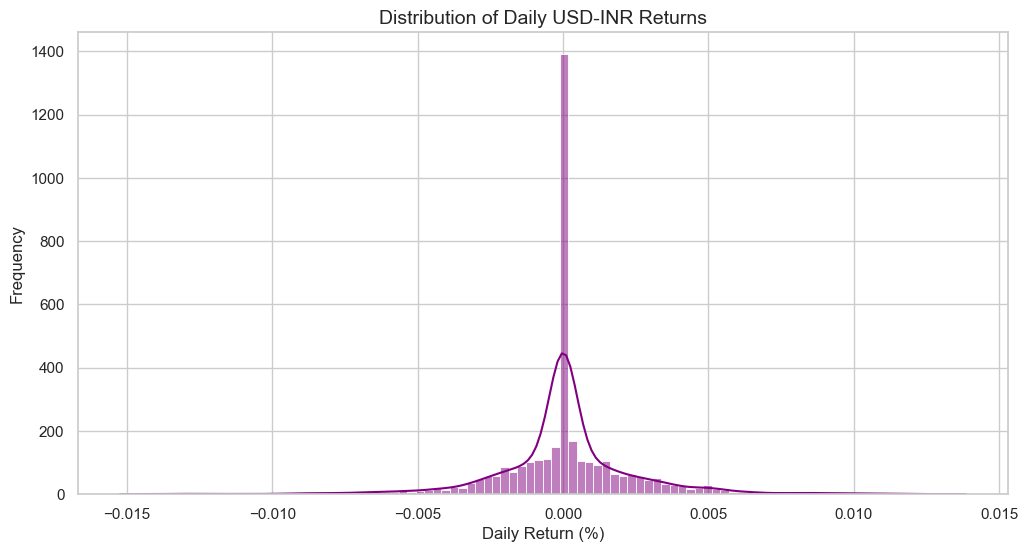

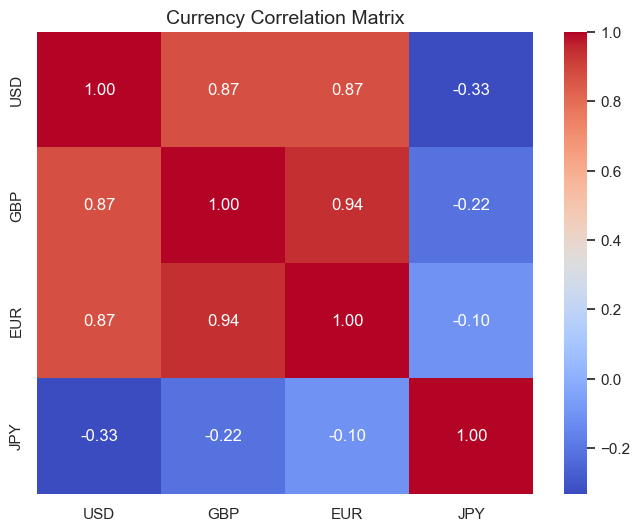

EDA Complete! 4 Key Plots saved to: ../outputs/plots/


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup Paths
PROCESSED_DATA_PATH = '../data/processed/cleaned_fx_data.csv'
IMAGE_DIR = '../outputs/plots/'
os.makedirs(IMAGE_DIR, exist_ok=True)

# 2. Load the Cleaned Data
df = pd.read_csv(PROCESSED_DATA_PATH, index_col=0, parse_dates=True)

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- PLOT 1: Multi-Currency Trend Analysis ---
# Significance: Shows the long-term devaluation of INR against major currencies.
plt.figure()
for cur in ['USD', 'GBP', 'EUR']:
    plt.plot(df.index, df[cur], label=cur)
plt.title('FX Trend Analysis (2016-2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Exchange Rate (INR)')
plt.legend()
plt.savefig(f'{IMAGE_DIR}currency_trends.png')
plt.show()

# --- PLOT 2: The "Nervousness" Plot (USD Volatility) ---
# Significance: Highlights "Market Stress" periods (e.g., 2020 COVID, etc.)
# This justifies WHY the business needs a Risk Engine.
plt.figure()
plt.plot(df.index, df['USD_Volatility'], color='red', label='USD 30-Day Volatility')
plt.title('USD-INR Market Volatility (Market Stress Spikes)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Volatility (Std Dev of Returns)')
plt.fill_between(df.index, df['USD_Volatility'], color='red', alpha=0.1)
plt.savefig(f'{IMAGE_DIR}usd_volatility.png')
plt.show()

# --- PLOT 3: Distribution of Returns (The "Stability" Check) ---
# Significance: Shows if the currency usually stays stable or has "fat tails" (extreme jumps).
plt.figure()
sns.histplot(df['USD_Return'].dropna(), kde=True, bins=100, color='purple')
plt.title('Distribution of Daily USD-INR Returns', fontsize=14)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.savefig(f'{IMAGE_DIR}returns_distribution.png')
plt.show()

# --- PLOT 4: Correlation Heatmap ---
# Significance: Shows how currencies move together. 
# Useful for "Hedging" (e.g., if you have USD revenue and GBP costs).
plt.figure(figsize=(8, 6))
corr_matrix = df[['USD', 'GBP', 'EUR', 'JPY']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Currency Correlation Matrix', fontsize=14)
plt.savefig(f'{IMAGE_DIR}correlation_heatmap.png')
plt.show()

print(f"EDA Complete! 4 Key Plots saved to: {IMAGE_DIR}")